# Retailrocket E-commerce Funnel Analysis
## Notebook 03 — Item and Category Analysis

### Цель ноутбука
В этом ноутбуке:
- анализируется воронка на уровне товаров;
- извлекаются категории товаров из item properties;
- строится воронка по категориям;
- выявляются товары и категории с высоким интересом, но низкой конверсией;
- формулируются продуктовые рекомендации.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
events = pd.read_csv('data/events_clean.csv')
events.head()

,Unnamed: 0,timestamp,visitorid,event,itemid,transactionid,event_time,event_date,event_week,event_month,event_hour,event_dayofweek
0,0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
1,1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
2,2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
3,3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday
4,4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,2015-06-02,2015-06-01/2015-06-07,2015-06,5,Tuesday


In [3]:
item_properties_1 = pd.read_csv('data/item_properties_part1.csv')
item_properties_2 = pd.read_csv('data/item_properties_part2.csv')
category_tree = pd.read_csv('data/category_tree.csv')

## 2. Воронка на уровне товаров

Сначала построим агрегаты по товарам:
- число просмотров,
- число добавлений в корзину,
- число покупок,
- конверсии между этапами.

In [4]:
item_event_counts = (
    pd.crosstab(events["itemid"], events["event"])
    .reset_index()
)
for col in ["view", "addtocart", "transaction"]:
    if col not in item_event_counts.columns:
        item_event_counts[col] = 0
item_event_counts = item_event_counts.rename(columns={
    "view": "views",
    "addtocart": "addtocarts",
    "transaction": "transactions"
})
item_event_counts.head()

event,itemid,addtocarts,transactions,views
0,3,0,0,2
1,4,0,0,3
2,6,0,0,29
3,9,0,0,2
4,15,3,1,18


In [5]:
item_metrics = item_event_counts.copy()
item_metrics["cr_view_to_cart"] = np.where(
    item_metrics["views"] > 0,
    item_metrics["addtocarts"] / item_metrics["views"],
    np.nan
)
item_metrics["cr_cart_to_transaction"] = np.where(
    item_metrics["addtocarts"] > 0,
    item_metrics["transactions"] / item_metrics["addtocarts"],
    np.nan
)
item_metrics["cr_view_to_transaction"] = np.where(
    item_metrics["views"] > 0,
    item_metrics["transactions"] / item_metrics["views"],
    np.nan
)
item_metrics.head()

event,itemid,addtocarts,transactions,views,cr_view_to_cart,cr_cart_to_transaction,cr_view_to_transaction
0,3,0,0,2,0.000000,NaN,0.000000
1,4,0,0,3,0.000000,NaN,0.000000
2,6,0,0,29,0.000000,NaN,0.000000
3,9,0,0,2,0.000000,NaN,0.000000
4,15,3,1,18,0.166667,0.333333,0.055556


In [6]:
top_items_by_views = item_metrics.sort_values("views", ascending=False).head(10)
top_items_by_views

event,itemid,addtocarts,transactions,views,cr_view_to_cart,cr_cart_to_transaction,cr_view_to_transaction
94720,187946,2,0,3410,0.000587,0.000000,0.000000
232496,461686,304,133,2538,0.119779,0.437500,0.052403
2719,5411,9,0,2325,0.003871,0.000000,0.000000
186716,370653,0,0,1854,0.000000,NaN,0.000000
110536,219512,48,12,1740,0.027586,0.250000,0.006897
150148,298009,0,0,1642,0.000000,NaN,0.000000
49024,96924,0,0,1633,0.000000,NaN,0.000000
156023,309778,48,15,1565,0.030671,0.312500,0.009585
129504,257040,89,27,1531,0.058132,0.303371,0.017636
193605,384302,65,15,1528,0.042539,0.230769,0.009817


<Figure size 1000x600 with 0 Axes>

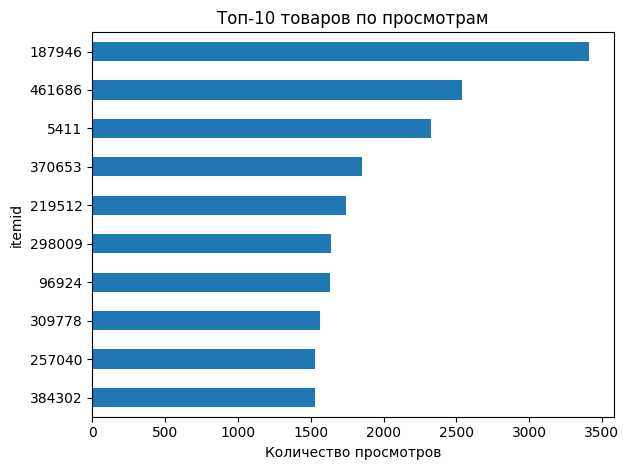

In [7]:
plt.figure(figsize=(10, 6))
top_items_by_views.sort_values("views").plot(
    x="itemid", y="views", kind="barh", legend=False
)
plt.title("Топ-10 товаров по просмотрам")
plt.xlabel("Количество просмотров")
plt.ylabel("itemid")
plt.tight_layout()
plt.show()

In [8]:
high_interest_low_conversion_items = item_metrics[
    (item_metrics["views"] >= item_metrics["views"].quantile(0.95)) &
    (item_metrics["cr_view_to_transaction"] <= item_metrics["cr_view_to_transaction"].quantile(0.25))
].sort_values(["views", "cr_view_to_transaction"], ascending=[False, True])
high_interest_low_conversion_items.head(20)

event,itemid,addtocarts,transactions,views,cr_view_to_cart,cr_cart_to_transaction,cr_view_to_transaction
94720,187946,2,0,3410,0.000587,0.0,0.0
2719,5411,9,0,2325,0.003871,0.0,0.0
186716,370653,0,0,1854,0.000000,NaN,0.0
150148,298009,0,0,1642,0.000000,NaN,0.0
49024,96924,0,0,1633,0.000000,NaN,0.0
169261,335975,0,0,1428,0.000000,NaN,0.0
76432,151444,0,0,1230,0.000000,NaN,0.0
71944,142466,1,0,1135,0.000881,0.0,0.0
218935,434782,0,0,1069,0.000000,NaN,0.0
46393,91755,0,0,1024,0.000000,NaN,0.0


In [9]:
high_cart_low_purchase_items = item_metrics[
    (item_metrics["addtocarts"] >= item_metrics["addtocarts"].quantile(0.95)) &
    (item_metrics["cr_cart_to_transaction"] <= item_metrics["cr_cart_to_transaction"].quantile(0.25))
].sort_values(["addtocarts", "cr_cart_to_transaction"], ascending=[False, True])
high_cart_low_purchase_items.head(20)

event,itemid,addtocarts,transactions,views,cr_view_to_cart,cr_cart_to_transaction,cr_view_to_transaction
24955,49242,26,0,38,0.684211,0.0,0.0
188803,374855,26,0,23,1.130435,0.0,0.0
221021,438823,24,0,80,0.300000,0.0,0.0
66099,130771,20,0,11,1.818182,0.0,0.0
194956,386947,19,0,320,0.059375,0.0,0.0
107097,212650,16,0,220,0.072727,0.0,0.0
123124,244528,16,0,65,0.246154,0.0,0.0
136009,269953,15,0,117,0.128205,0.0,0.0
233162,462988,15,0,27,0.555556,0.0,0.0
10066,20027,14,0,29,0.482759,0.0,0.0


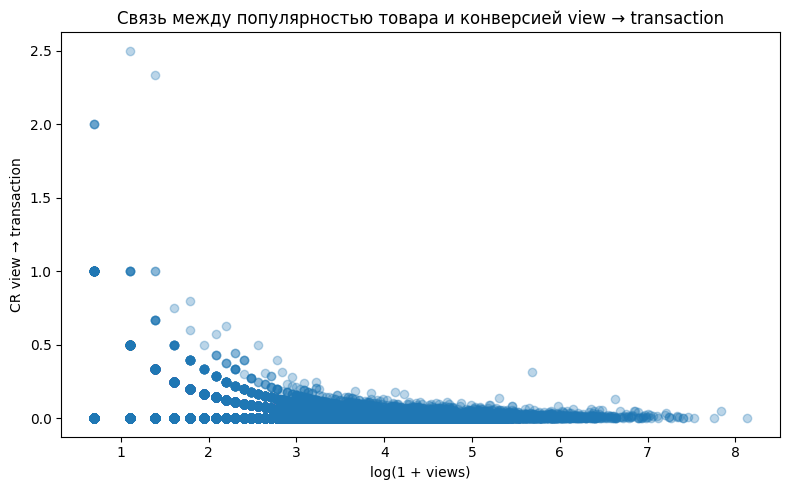

In [10]:
plot_data = item_metrics[
    (item_metrics["views"] > 0) &
    item_metrics["cr_view_to_transaction"].notna()
].copy()

plt.figure(figsize=(8, 5))
plt.scatter(
    np.log1p(plot_data["views"]),
    plot_data["cr_view_to_transaction"],
    alpha=0.3
)
plt.title("Связь между популярностью товара и конверсией view → transaction")
plt.xlabel("log(1 + views)")
plt.ylabel("CR view → transaction")
plt.tight_layout()
plt.show()

## 3. Извлечение категорий товаров

Категория товара хранится не в `events.csv`, а в `item_properties`.
Нужно объединить обе части item properties и извлечь свойство `categoryid`.

In [11]:
item_properties = pd.concat([item_properties_1, item_properties_2], ignore_index=True)
item_properties.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [12]:
item_categories = item_properties[item_properties["property"] == "categoryid"].copy()
item_categories.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
140,1432436400000,281245,categoryid,1277
151,1435460400000,35575,categoryid,1059
189,1437274800000,8313,categoryid,1147
197,1437879600000,55102,categoryid,47


In [13]:
item_categories["timestamp"] = pd.to_datetime(item_categories["timestamp"], unit="ms", errors="coerce")
item_categories.head()

,timestamp,itemid,property,value
0,2015-06-28 03:00:00,460429,categoryid,1338
140,2015-05-24 03:00:00,281245,categoryid,1277
151,2015-06-28 03:00:00,35575,categoryid,1059
189,2015-07-19 03:00:00,8313,categoryid,1147
197,2015-07-26 03:00:00,55102,categoryid,47


In [14]:
item_categories = (
    item_categories.sort_values(["itemid", "timestamp"])
    .groupby("itemid")
    .tail(1)
    .copy()
)
item_categories = item_categories[["itemid", "value"]].rename(columns={"value": "categoryid"})
item_categories.head()

,itemid,categoryid
19220984,0,209
8428979,1,1114
9157980,2,1305
3828355,3,1171
19767463,4,1038


In [15]:
item_categories["categoryid"] = pd.to_numeric(item_categories["categoryid"], errors="coerce")
item_categories["categoryid"] = item_categories["categoryid"].astype("Int64")

In [16]:
item_metrics = item_metrics.merge(item_categories, on="itemid", how="left")
print("Доля товаров с найденной категорией:", round(item_metrics["categoryid"].notna().mean(), 4))
item_metrics.head()

Доля товаров с найденной категорией: 0.7881


,itemid,addtocarts,transactions,views,cr_view_to_cart,cr_cart_to_transaction,cr_view_to_transaction,categoryid
0,3,0,0,2,0.000000,NaN,0.000000,1171
1,4,0,0,3,0.000000,NaN,0.000000,1038
2,6,0,0,29,0.000000,NaN,0.000000,1091
3,9,0,0,2,0.000000,NaN,0.000000,<NA>
4,15,3,1,18,0.166667,0.333333,0.055556,722


## 4. Воронка на уровне категорий

Теперь агрегируем товарные метрики до уровня категорий

In [17]:
category_metrics = (
    item_metrics.groupby("categoryid", dropna=False)
    .agg(
        items=("itemid", "nunique"),
        views=("views", "sum"),
        addtocarts=("addtocarts", "sum"),
        transactions=("transactions", "sum")
    )
    .reset_index()
)
category_metrics.head()

,categoryid,items,views,addtocarts,transactions
0,0,95,1049,58,12
1,1,641,5846,391,80
2,3,246,2375,58,15
3,4,23,144,12,10
4,5,288,28952,576,186


In [18]:
category_metrics["cr_view_to_cart"] = np.where(
    category_metrics["views"] > 0,
    category_metrics["addtocarts"] / category_metrics["views"],
    np.nan
)
category_metrics["cr_cart_to_transaction"] = np.where(
    category_metrics["addtocarts"] > 0,
    category_metrics["transactions"] / category_metrics["addtocarts"],
    np.nan
)
category_metrics["cr_view_to_transaction"] = np.where(
    category_metrics["views"] > 0,
    category_metrics["transactions"] / category_metrics["views"],
    np.nan
)
category_metrics.head()

,categoryid,items,views,addtocarts,transactions,cr_view_to_cart,cr_cart_to_transaction,cr_view_to_transaction
0,0,95,1049,58,12,0.055291,0.206897,0.011439
1,1,641,5846,391,80,0.066883,0.204604,0.013685
2,3,246,2375,58,15,0.024421,0.258621,0.006316
3,4,23,144,12,10,0.083333,0.833333,0.069444
4,5,288,28952,576,186,0.019895,0.322917,0.006424


In [19]:
category_metrics = category_metrics.merge(
    category_tree,
    on="categoryid",
    how="left"
)
category_metrics.head()

,categoryid,items,views,addtocarts,transactions,cr_view_to_cart,cr_cart_to_transaction,cr_view_to_transaction,parentid
0,0,95,1049,58,12,0.055291,0.206897,0.011439,605.0
1,1,641,5846,391,80,0.066883,0.204604,0.013685,854.0
2,3,246,2375,58,15,0.024421,0.258621,0.006316,1281.0
3,4,23,144,12,10,0.083333,0.833333,0.069444,1266.0
4,5,288,28952,576,186,0.019895,0.322917,0.006424,1637.0


In [20]:
top_categories_by_views = (
    category_metrics[category_metrics["categoryid"].notna()]
    .sort_values("views", ascending=False)
    .head(10)
)
top_categories_by_views

,categoryid,items,views,addtocarts,transactions,cr_view_to_cart,cr_cart_to_transaction,cr_view_to_transaction,parentid
676,1051,2557,73014,1709,485,0.023406,0.283792,0.006643,955.0
961,1483,2945,62785,1520,469,0.024210,0.308553,0.007470,561.0
322,491,2417,59298,1548,263,0.026105,0.169897,0.004435,679.0
615,959,1890,50112,1633,532,0.032587,0.325781,0.010616,1095.0
222,342,4697,45288,1278,281,0.028219,0.219875,0.006205,500.0
445,683,939,37765,907,211,0.024017,0.232635,0.005587,1606.0
823,1279,1023,33531,720,123,0.021473,0.170833,0.003668,1606.0
4,5,288,28952,576,186,0.019895,0.322917,0.006424,1637.0
426,646,1381,27669,484,87,0.017493,0.179752,0.003144,1606.0
32,48,1039,26701,600,146,0.022471,0.243333,0.005468,500.0


<Figure size 1000x600 with 0 Axes>

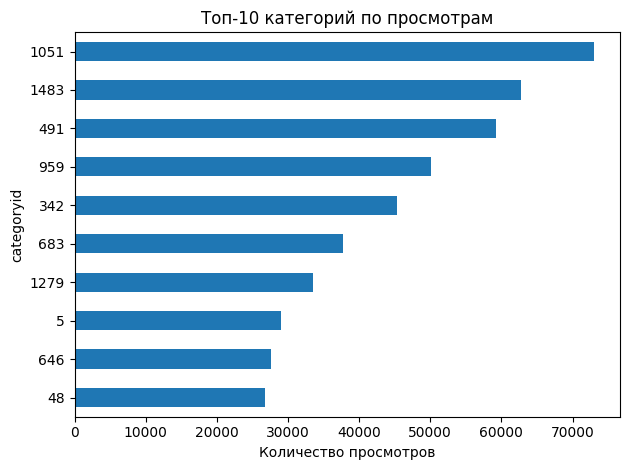

In [21]:
plt.figure(figsize=(10, 6))
top_categories_by_views.sort_values("views").plot(
    x="categoryid", y="views", kind="barh", legend=False
)
plt.title("Топ-10 категорий по просмотрам")
plt.xlabel("Количество просмотров")
plt.ylabel("categoryid")
plt.tight_layout()
plt.show()

In [22]:
top_categories_by_transactions = (
    category_metrics[category_metrics["categoryid"].notna()]
    .sort_values("transactions", ascending=False)
    .head(10)
)
top_categories_by_transactions

,categoryid,items,views,addtocarts,transactions,cr_view_to_cart,cr_cart_to_transaction,cr_view_to_transaction,parentid
615,959,1890,50112,1633,532,0.032587,0.325781,0.010616,1095.0
676,1051,2557,73014,1709,485,0.023406,0.283792,0.006643,955.0
961,1483,2945,62785,1520,469,0.024210,0.308553,0.007470,561.0
126,196,1659,26645,740,298,0.027773,0.402703,0.011184,1667.0
994,1542,1006,12853,662,294,0.051505,0.444109,0.022874,745.0
407,618,1460,14535,709,285,0.048779,0.401975,0.019608,105.0
222,342,4697,45288,1278,281,0.028219,0.219875,0.006205,500.0
322,491,2417,59298,1548,263,0.026105,0.169897,0.004435,679.0
746,1163,718,7157,372,259,0.051977,0.696237,0.036188,561.0
920,1421,1315,9376,613,246,0.065380,0.401305,0.026237,105.0


<Figure size 1000x600 with 0 Axes>

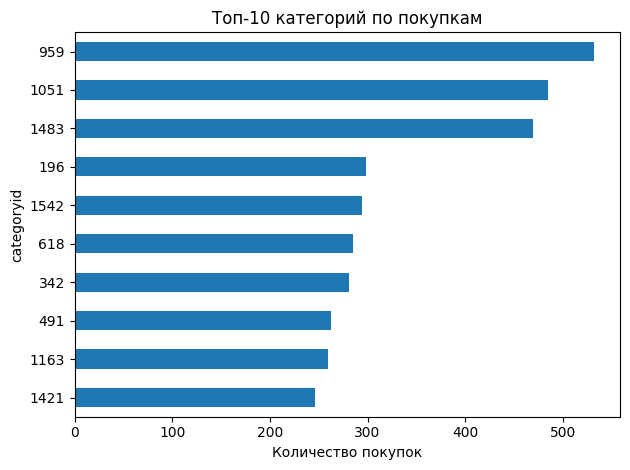

In [23]:
plt.figure(figsize=(10, 6))
top_categories_by_transactions.sort_values("transactions").plot(
    x="categoryid", y="transactions", kind="barh", legend=False
)
plt.title("Топ-10 категорий по покупкам")
plt.xlabel("Количество покупок")
plt.ylabel("categoryid")
plt.tight_layout()
plt.show()

In [27]:
category_metrics_valid = category_metrics[
    category_metrics["categoryid"].notna() &
    category_metrics["cr_view_to_transaction"].notna()
].copy()
high_interest_low_conversion_categories = category_metrics_valid[
    (category_metrics_valid["views"] >= category_metrics_valid["views"].quantile(0.75)) &
    (category_metrics_valid["cr_view_to_transaction"] <= category_metrics_valid["cr_view_to_transaction"].quantile(0.40))
].sort_values(["views", "cr_view_to_transaction"], ascending=[False, True])
high_interest_low_conversion_categories.head(20)

,categoryid,items,views,addtocarts,transactions,cr_view_to_cart,cr_cart_to_transaction,cr_view_to_transaction,parentid
328,499,569,13440,266,16,0.019792,0.060150,0.001190,986.0
958,1477,929,13370,187,14,0.013987,0.074866,0.001047,206.0
278,429,950,12917,105,30,0.008129,0.285714,0.002323,113.0
42,64,1072,10566,248,22,0.023472,0.088710,0.002082,206.0
759,1188,391,8044,98,14,0.012183,0.142857,0.001740,1497.0
512,789,289,7988,62,8,0.007762,0.129032,0.001002,14.0
532,818,280,6618,67,15,0.010124,0.223881,0.002267,852.0
858,1325,260,6243,47,7,0.007528,0.148936,0.001121,1684.0
643,999,453,5955,33,14,0.005542,0.424242,0.002351,1621.0
430,656,224,5549,38,9,0.006848,0.236842,0.001622,1125.0


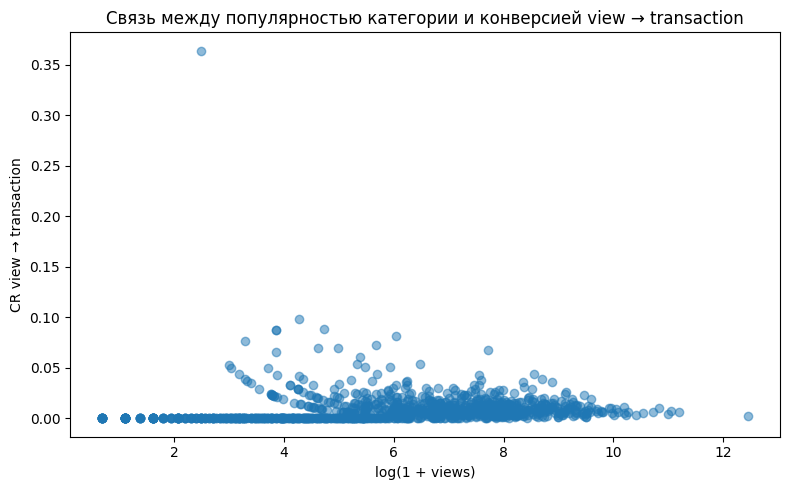

In [28]:
category_plot_data = category_metrics[
    (category_metrics["views"] > 0) &
    category_metrics["cr_view_to_transaction"].notna()
].copy()
plt.figure(figsize=(8, 5))
plt.scatter(
    np.log1p(category_plot_data["views"]),
    category_plot_data["cr_view_to_transaction"],
    alpha=0.5
)
plt.title("Связь между популярностью категории и конверсией view → transaction")
plt.xlabel("log(1 + views)")
plt.ylabel("CR view → transaction")
plt.tight_layout()
plt.show()

## Возможные наблюдения

1. Часть товаров и категорий генерирует высокий интерес пользователей, но слабо конвертируется в покупку.
   Это может указывать на:
   - слабую карточку товара
   - неудачное ценовое позиционирование
   - недостаток доверия
   - проблему с ассортиментом внутри категории

2. Есть товары с высоким числом добавлений в корзину, но низким переходом в покупку.
   Это может быть связано с:
   - ценовым барьером
   - сравнением с альтернативами
   - фрикцией на поздних стадиях пути пользователя

3. Есть категории с относительно высокой конверсией при небольшом объеме просмотров.
   Такие категории могут быть кандидатами на дополнительное продвижение, так как уже демонстрируют качественный спрос.

4. Различие между популярностью и конверсией показывает, что высокий трафик сам по себе не означает высокую бизнес-эффективность.